In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"]="0"

# Basic Structure / Three Pillars

This notebook shows the basic workflow of (medical) image classification with ``AUCMEDI``.  

The three pillars of the basic structure are:
1. the Data Interface
2. the NeuralNetwork
3. the DataGenerator  

Have a look at the general workflow [here](https://frankkramer-lab.github.io/aucmedi/workflow/).

But first, we have to load the data...

## Downloading the data

In [2]:
import os
datadir = os.path.join(os.getcwd(), "data")

from pathlib import Path

Path(datadir).mkdir(parents=True, exist_ok=True)

import wget

zip_path = os.path.join(datadir, "Kather_texture_2016_image_tiles_5000.zip")

if not os.path.exists(zip_path):
    print('Beginning file download with wget module')
    url = 'https://zenodo.org/record/53169/files/Kather_texture_2016_image_tiles_5000.zip?download=1'
    wget.download(url, zip_path)
else:
    print('Zip already downloaded, skipping download.')

# unzip the data

import zipfile
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(datadir)

Zip already downloaded, skipping download.


Now we have downloaded our data and unzipped them.  
The way these data come, pictures of each class are in stored in a seperate folder, like so:

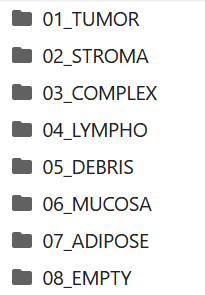

This is pretty useful, because we can directly use the folder-structure to load the corresponding labels to the data.

## Pillar 1: Input interface

The ``input_interface`` of ``AUCMEDI`` reads the data and labels from ``directory``, from ``csv`` or from ``json``. Here we are going to read them from ``directory``. (If you want to learn how to read data/labels from ``csv``, have a look in the corresponding notebook.)  

``training`` is set to ``True``, because the directory-structure contains label information and thus annotation data is available.  

``path_data`` is set to ``None`` because we don't have our label information stored in a seperate file.

The ``input_interface`` gives back some useful information that we are going to use later.

In [3]:
from aucmedi.data_processing.io_data import input_interface
ds_loader = input_interface("directory", path_imagedir="data/Kather_texture_2016_image_tiles_5000", path_data=None, training=True, ohe=False)
(samples, class_ohe, nclasses, class_names, image_format) = ds_loader

E:\Daten\Uni\MISIT\MyFork\aucmedi\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The ``ds_loader`` gives back the ``samples``, the ``classes`` in one hot encoded form, the number of classes (``nclasses``), the ``class_names`` and the ``image_format``.  

``samples`` is a list of the image-names:

In [4]:
samples[0:3]

['01_TUMOR\\10009_CRC-Prim-HE-03_009.tif_Row_301_Col_151.tif',
 '01_TUMOR\\10062_CRC-Prim-HE-02_003b.tif_Row_1_Col_301.tif',
 '01_TUMOR\\100B0_CRC-Prim-HE-09_009.tif_Row_1_Col_301.tif']

``class_ohe`` is a list of the corresponding labels in one hot encoded form:

In [5]:
class_ohe[0:3]

array([[1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0],
       [1, 0, 0, 0, 0, 0, 0, 0]], dtype=uint8)

``nclasses`` tells us how many classes we have in our dataset:

In [6]:
nclasses

8

The names of all classes are stored in the list ``class_names``:

In [7]:
class_names

['01_TUMOR',
 '02_STROMA',
 '03_COMPLEX',
 '04_LYMPHO',
 '05_DEBRIS',
 '06_MUCOSA',
 '07_ADIPOSE',
 '08_EMPTY']

Image format refers to the string that need to be added at the end of the sample index for image loading. Since our image-strings already contain the format-string it is ``None`` here.

In [8]:
print(image_format)

None


Now that we have loaded the data, we can defining a train, validation and test-set.

In [9]:
from aucmedi.sampling.split import sampling_split
train, validation, test = sampling_split(samples, class_ohe, sampling=[0.5, 0.25, 0.25], stratified=True, iterative=False, seed=123)

Afterwards we will define the model (Pillar 2, ``NeuralNetwork``), prepare batches of images for training (Pillar 3, ``DataLoader``). After that we can train our model and evaluate it.

## Pillar 2: NeuralNetwork

Now we are defining our ``NeuralNetwork`` model.  

The ``NeuralNetwork`` interface is build on top of pytorch and allows binary, multi-class and multi-label classification.  
We could also include ``metadata`` (such as age or blood-values). If you are interested in that, have a look in the corresponding notebook.  

Furthermore we could use predefined architectures like ``ResNet`` or ``EfficientNet`` or many others for [2D](https://frankkramer-lab.github.io/aucmedi/reference/neural_network/architectures/image/#aucmedi.neural_network.architectures.image) or [3D](https://frankkramer-lab.github.io/aucmedi/reference/neural_network/architectures/volume/#aucmedi.neural_network.architectures.volume) data. If you want to do this, just include the argument ``architecture`` when defining the model and specify which architecture you would like to use, for example: ``architecture="2D.ResNet50"``. There is also a notebook dedicated to this topic. Here we will use the standard architecture of ``AUCMEDI``.

Here is a quick explanation of the other arguments of the ``NeuralNetwork`` initalization:
* `n_labels` is 8, since we have 8 classes. But we don't need to know this, because the input_interface gives back this information
* `channels = 3`, because the images are in RGB format (3 color channels)
* `loss = torch.nn.CrossEntropyLoss(),`, because that loss is prefered for multiclass classification problems
* `activation_output = "softmax"`, because softmax turns the activations of the last layer into a probability distribution. That means, the total sum probabilities of classes will be 1.
* `pretrained_weights=False` because we are not using transferlearning here. If you want to learn about transferlearning, have a look in the according notebook.

In [10]:
from aucmedi.neural_network.model import NeuralNetwork
import torch


model = NeuralNetwork(n_labels=nclasses, channels=3, loss=torch.nn.CrossEntropyLoss(), activation_output="softmax")

## Pillar 3: DataGenerator

Now, the model can be trained.  

Since the model expects batches of training samples, we create a `DataGenerator` wrapped in a generic pytorch `DataLoader` by calling `create_batch_loader`. 
Two `DataLoader`s are defined here, one for the training set and one for the validation set. (Another `DataLoader` for the test set will be defined later, it could just as well defined here. But it is only needed later on.)  

The `DataLoader`s take as samples the lists of images of the train and validation-set, respectively (`train[0]` and `validation[0]`). Since those are strings of image names, `path_imagedir` tells the `DataLoader` were those images can be found.  

The `labels` (`train[1]` and `validation[1]`) are the one-hot-encoded labels of the corresponding images. The one-hot-encoding was performed by the `input_interface`.  

For the arguments `resize` and `standardize_mode` the standard-values of the model are applied.  

Likewise the `image_format` is the `image_format` of the images, that is given back by the `input_interface`.

In [11]:
from aucmedi.data_processing.data_generator import create_batch_loader

train_generator = create_batch_loader(samples=train[0], path_imagedir="data/Kather_texture_2016_image_tiles_5000",
                                               resize=model.arch_resolution, standardize_mode=model.arch_standardize,
                                               labels=train[1], image_format=image_format, batch_size=32, data_aug=None, 
                                               grayscale=False, subfunctions=[], prepare_images=False, 
                                               sample_weights=None, seed=123, workers=1)
val_generator = create_batch_loader(samples=validation[0], path_imagedir="data/Kather_texture_2016_image_tiles_5000",
                                             resize=model.arch_resolution, standardize_mode=model.arch_standardize,
                                             labels=validation[1], image_format=image_format, batch_size=32, data_aug=None, 
                                             grayscale=False, subfunctions=[], prepare_images=False, 
                                             sample_weights=None, seed=123, workers=1)

history = model.train(training_generator=train_generator, validation_generator=val_generator, epochs=20, iterations=None, 
                                         callbacks=[], transfer_learning=False)

Epoch 1/20, Loss: 1.7366,  Val Loss: 1.3354, Time: 34.55s


Epoch 2/20, Loss: 1.2250,  Val Loss: 1.0457, Time: 17.92s


Epoch 3/20, Loss: 1.0519,  Val Loss: 0.9308, Time: 18.01s


Epoch 4/20, Loss: 0.9557,  Val Loss: 0.8278, Time: 17.84s


Epoch 5/20, Loss: 0.8627,  Val Loss: 0.7355, Time: 16.56s


...

Epoch 16/20, Loss: 0.5485,  Val Loss: 0.4819, Time: 16.81s


Epoch 17/20, Loss: 0.5349,  Val Loss: 0.4963, Time: 17.12s


Epoch 18/20, Loss: 0.5370,  Val Loss: 0.4941, Time: 16.68s


Epoch 19/20, Loss: 0.5184,  Val Loss: 0.4802, Time: 16.85s


Epoch 20/20, Loss: 0.5131,  Val Loss: 0.4868, Time: 16.95s


Now we can evaluate the fitting of our model. (There is also a notebook on that topic.)

E:\Daten\Uni\MISIT\MyFork\aucmedi\.venv\lib\site-packages\plotnine\ggplot.py:587: PlotnineWarning: Saving 6.4 x 4.8 in image.
E:\Daten\Uni\MISIT\MyFork\aucmedi\.venv\lib\site-packages\plotnine\ggplot.py:588: PlotnineWarning: Filename: plot.fitting_course.validation.png


E:\Daten\Uni\MISIT\MyFork\aucmedi\.venv\lib\site-packages\plotnine\themes\themeable.py:1902: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.
E:\Daten\Uni\MISIT\MyFork\aucmedi\.venv\lib\site-packages\plotnine\themes\themeable.py:1902: FutureWarning: You no longer need to use subplots_adjust to make space for the legend or text around the panels. This paramater will be removed in a future version. You can still use 'plot_margin' 'panel_spacing' for your other spacing needs.


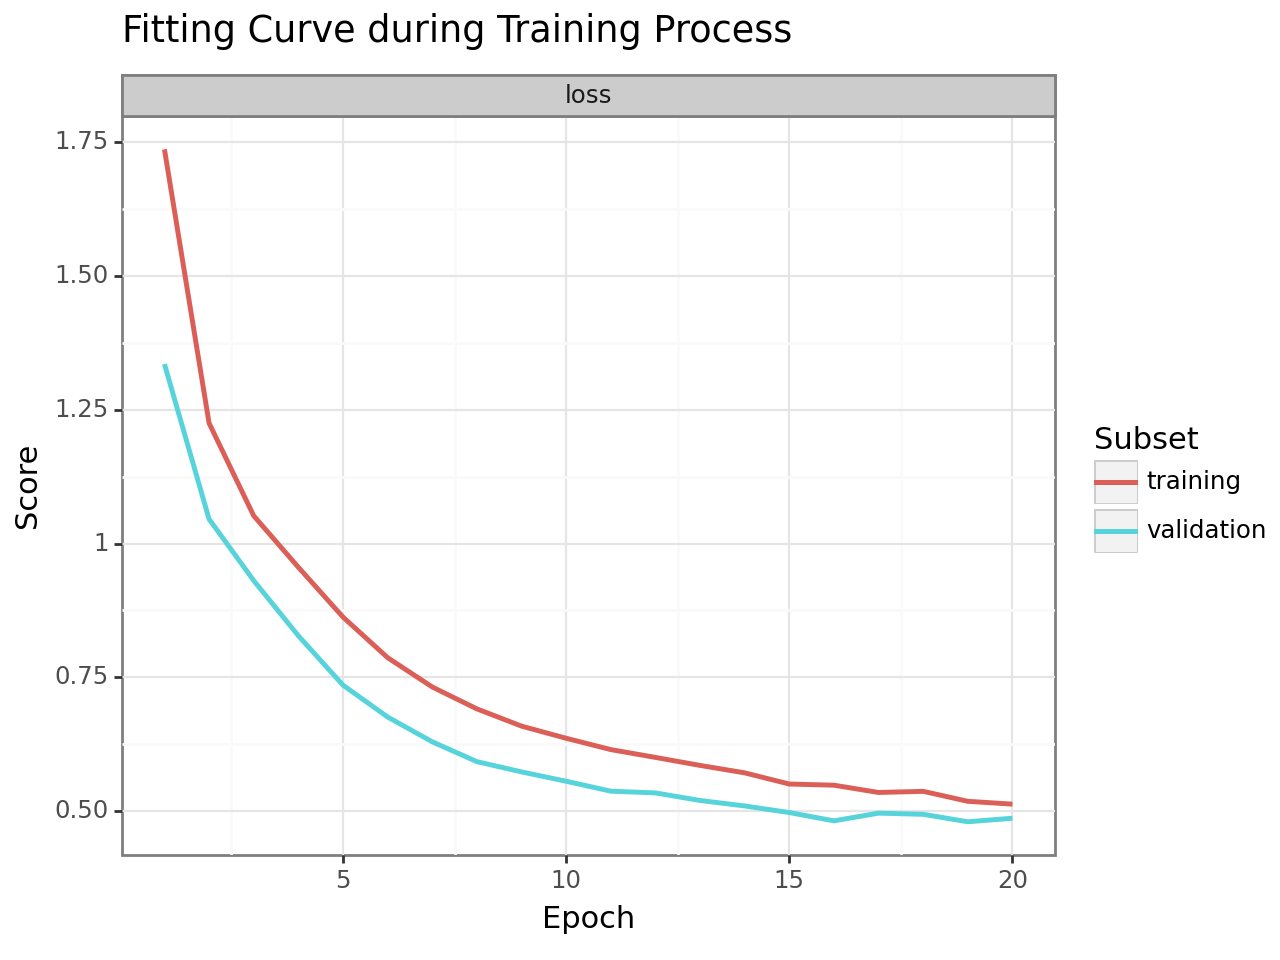

In [12]:
from aucmedi import *
from aucmedi.evaluation.fitting import *

evaluate_fitting(
    train_history = history,
    out_path = "./",
    monitor=["loss"],
    prefix_split=".",
    suffix="validation",
    show=True
)

## Evaluate Model on test data

Remember that we spiltted our data in three parts: train, validation and test.  
So far we have only used the train- and validation-set (during the training of the model). But we want to evaluate the performance on the model on a fresh, unseen data-set. That's what we are going to use the test-set for.  

First, we need a ``DataLoader`` to create batches of data here as well. This works just like it did for the training- and validation-generator, __but__ ``labels=None`` here (because we don't want to tell the model the true labels when predicting).

In [13]:
from aucmedi.data_processing.data_generator import create_batch_loader

predict_generator = create_batch_loader(samples=test[0], path_imagedir="data/Kather_texture_2016_image_tiles_5000",
                                                 resize=model.arch_resolution, standardize_mode=model.arch_standardize,
                                                 labels=None, image_format=image_format, batch_size=32, data_aug=None, 
                                                 shuffle=False, grayscale=False, subfunctions=[], prepare_images=False, 
                                                 sample_weights=None, seed=123, workers=1)



So now we can produce predictions using the ``predict_generator`` on the test-data.

In [14]:
prediction = model.predict(prediction_generator=predict_generator)

In order to evaluate the predictions, we are going to use ``AUCMEDI``s ``evaluate_performance``-function.  
It takes the predictions and the true (one hot encoded) labels (``test[1]`` in this case) as inputs and shows some informative evaluation plots, if ``show=True`` (otherwise the plot are just saved). 

E:\Daten\Uni\MISIT\MyFork\aucmedi\aucmedi\evaluation\performance.py:230: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


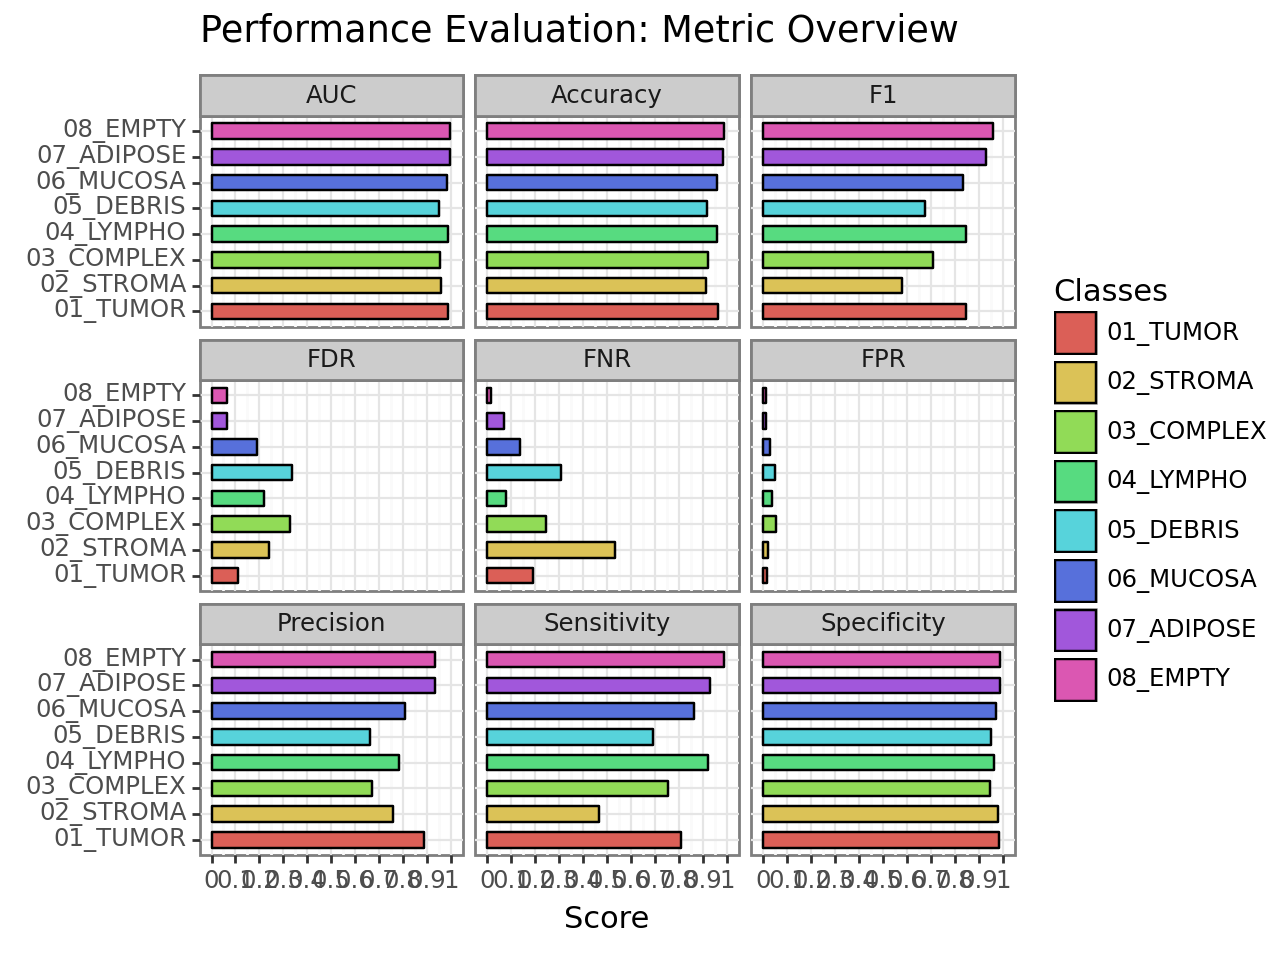

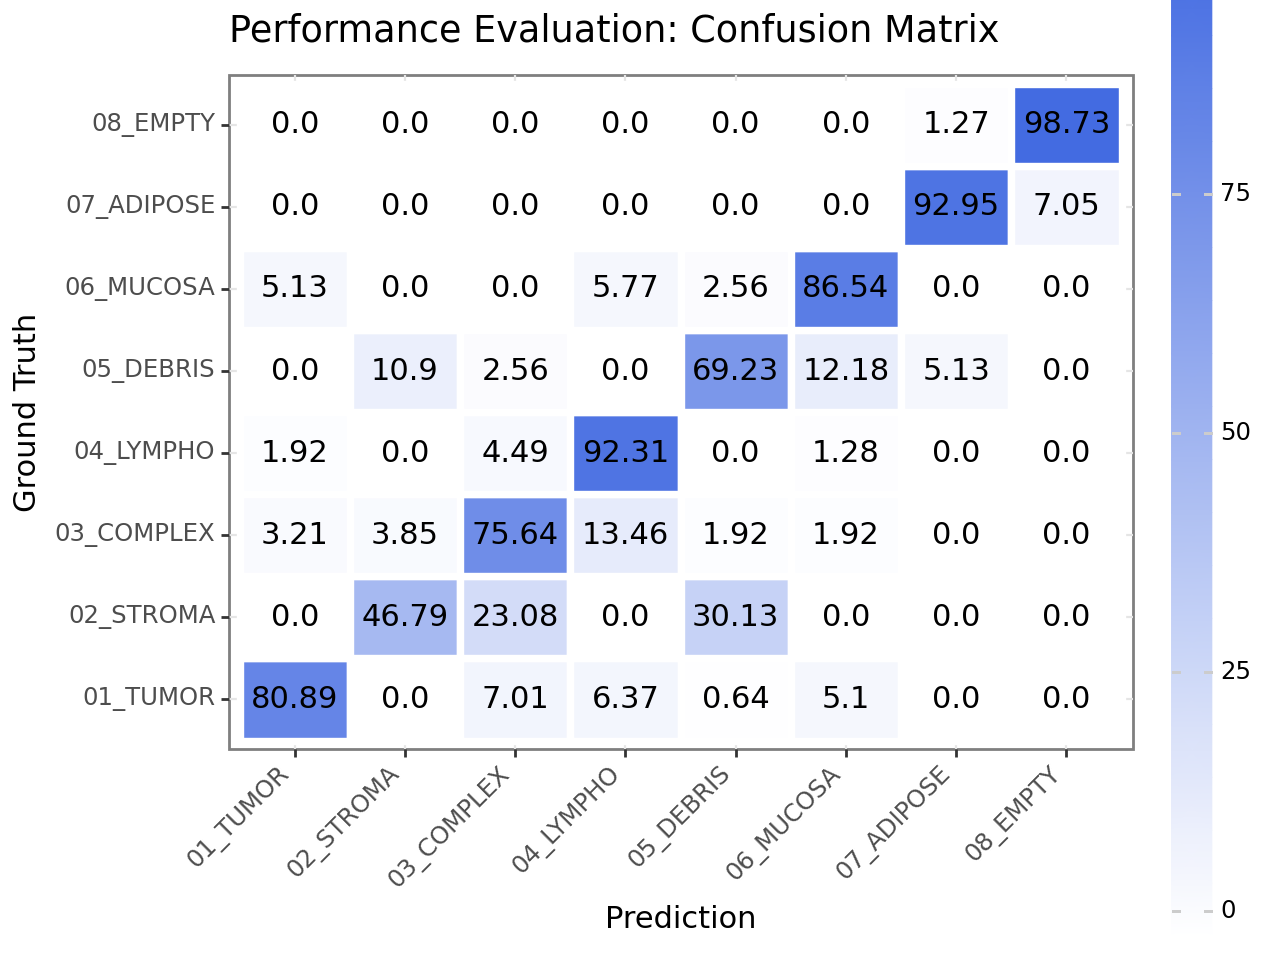

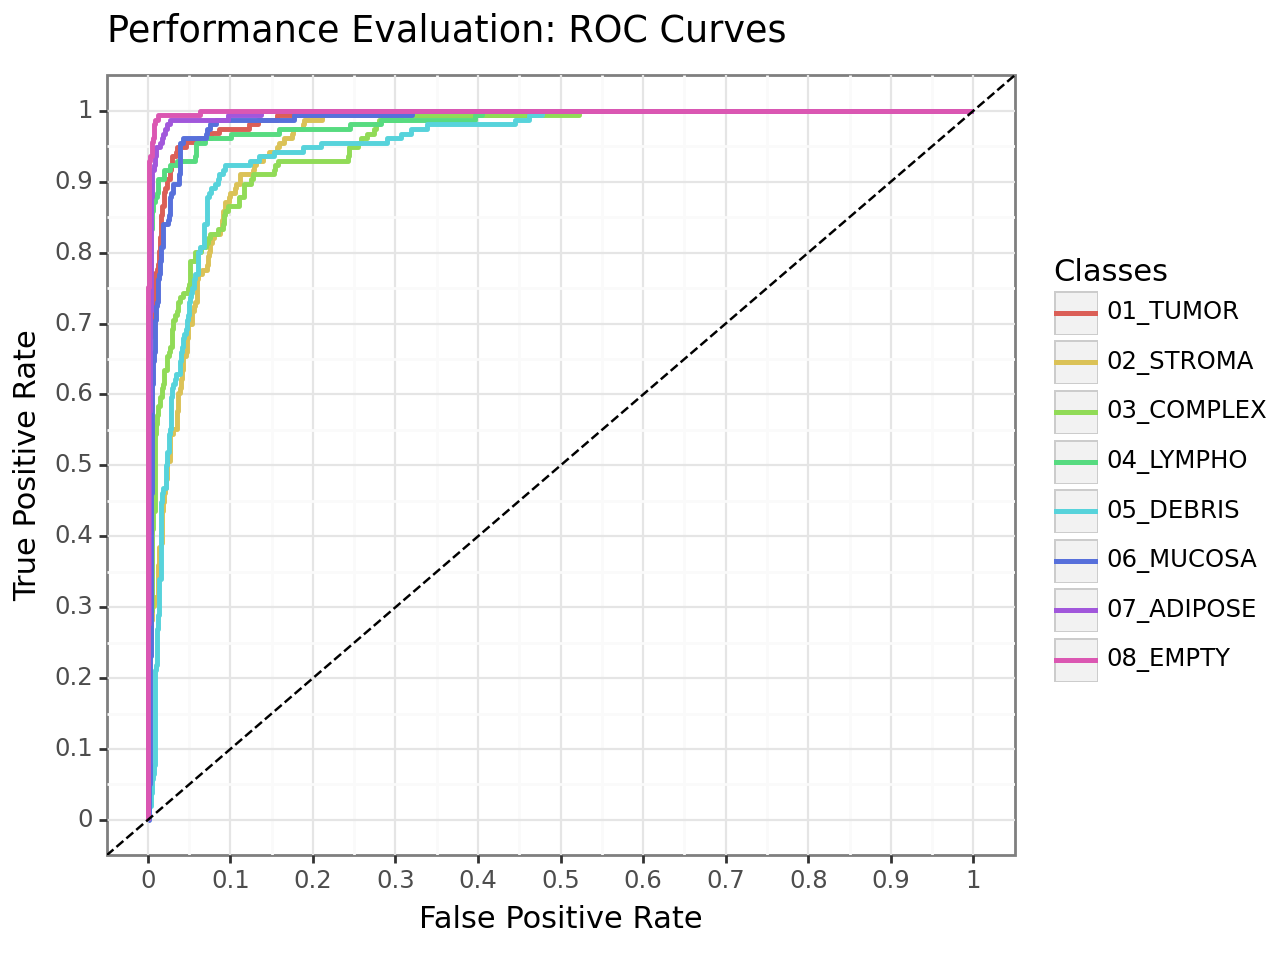

,metric,score,class
0,TP,127.000000,01_TUMOR
1,TN,1077.000000,01_TUMOR
2,FP,16.000000,01_TUMOR
3,FN,30.000000,01_TUMOR
4,Sensitivity,0.808917,01_TUMOR
...,...,...,...
99,FNR,0.012739,08_EMPTY
100,FDR,0.066265,08_EMPTY
101,Accuracy,0.989600,08_EMPTY
102,F1,0.959752,08_EMPTY


In [15]:
from aucmedi import *
from aucmedi.evaluation.performance import *

evaluate_performance(prediction, test[1], out_path=None, class_names=class_names, show=True)